In [14]:
# Imports and notebook-friendly path setup
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Make the repo root and src package available when running from the notebook kernel.
notebook_dir = Path.cwd()
repo_root_candidates = [
    notebook_dir,
    notebook_dir / "optics_gui_wx26_test",
    notebook_dir.parent / "optics_gui_wx26_test",
]
repo_root = next((p for p in repo_root_candidates if (p / "src").is_dir() and (p / "Dev" / "12_IO").is_dir()), notebook_dir)

src_path = repo_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from setupimp import RUN_FULL_MODEL, RUN_ORBIT_CORRECTION_EXAMPLE, repo_root as setup_repo_root
from optics_gui.snapshot import (
    SnapshotConfig,
    SnapshotOrbitCorrectionConfig,
    copy_snapshot_config,
    build_machine_snapshot,
)
from optics_gui.orbit_correction import (
    bpm_measurements_from_twiss,
    plot_orbit_with_bpm,
)


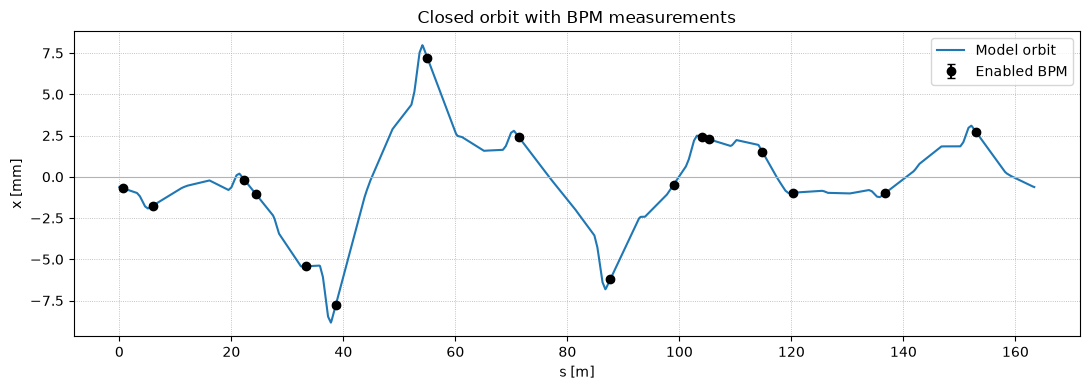

In [ ]:
if RUN_FULL_MODEL:
    if "error_orbit_snapshot" in globals():
        result_to_plot = error_orbit_snapshot
    elif "nominal_orbit_snapshot" in globals():
        result_to_plot = nominal_orbit_snapshot
    else:
        orbit_base_config = SnapshotConfig(
            cycle_time_ms=0.0,
            requested_qx=4.31,
            requested_qy=3.83,
            lattice_folder=str(repo_root / "Dev" / "Lattice_Files" / "00_Simplified_Lattice"),
            output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "orbit"),
            run_envelope=False,
            run_aperture=False,
        )
        nominal_orbit_config = copy_snapshot_config(
            orbit_base_config,
            snapshot_id="student_nominal_orbit",
            label="student nominal orbit",
            error_table_paths=[],
            orbit_correction_configs=[],
        )
        result_to_plot = build_machine_snapshot(nominal_orbit_config)

    ax = result_to_plot.table("orbit").plot(x="s", y=["x_mm", "y_mm"], figsize=(10, 4))
    ax.set_xlabel("s [m]")
    ax.set_ylabel("closed orbit [mm]")
    ax.set_title("Bare nominal model orbit")
    ax.grid(True, which="both", linestyle=":", linewidth=0.6)
else:
    print("Plot skipped because RUN_FULL_MODEL is False.")
